# 06 — O3 : réseau (préfecture)

Ce notebook **montre** les données de O3. Il ne produit aucun chiffre du 06 : ces chiffres viennent des CSV écrits par `scripts/exploration_06.py` (`data/analysis/06_exploration/`) et des tables du 05 (R-19). Il n'applique aucun seuil du 02, ne classe pas et ne calcule aucun score. Un écart est décrit, pas expliqué ; une date de la chronologie est une coïncidence, pas une cause (H1).

**Ce qu'on regarde** : la part des km évalués en mauvais état, les parts par état, les km non évalués, les km par type et par état par zone, les tronçons, l'état national de 2020 à 2022 et sa comparaison avec le relevé de 2020. L'état ne couvre que les routes nationales, relevées en 2020 (C).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_06 import *
appliquer_style()
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

In [2]:
p = prefectures_geo()

## Part des km évalués en mauvais état (O3-02)

Classes : quartiles des 39 préfectures (06 §4). Mô n'a aucune route classée : non défini, en gris.

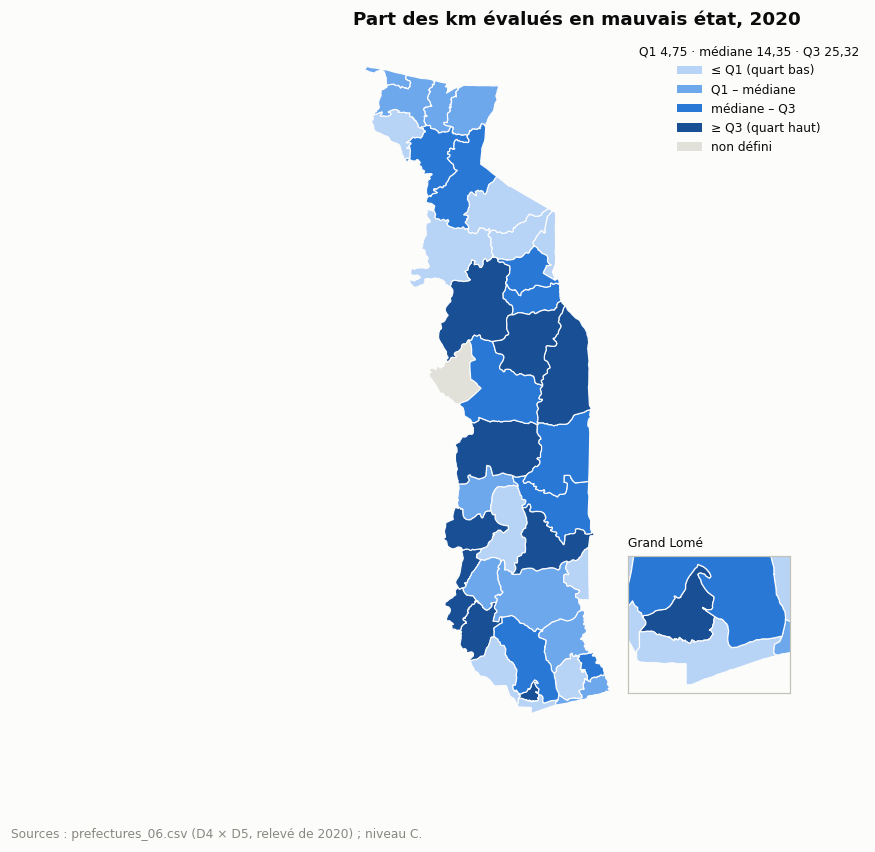

,Zone,Km évalués,Km mauvais,Part en mauvais état (%)
Préfecture,,,,
Agou,Plateaux,124.1,49.6,40.0
Agoè-Nyivé,Grand Lomé,27.8,7.2,26.0
Akébou,Plateaux,7.0,0.5,7.8
Amou,Plateaux,90.5,4.0,4.5
Anié,Plateaux,40.3,9.3,23.0
Assoli,Kara,72.5,15.8,21.8
Avé,Maritime hors Grand Lomé,110.8,3.0,2.7
Bas-Mono,Maritime hors Grand Lomé,35.8,7.6,21.1
Bassar,Kara,167.5,46.9,28.0


In [3]:
fig, ax, g = choroplethe(p, "Part en mauvais état (%)", "Part des km évalués en mauvais état, 2020",
                        "Sources : prefectures_06.csv (D4 × D5, relevé de 2020) ; niveau C.")
plt.show()
display(p[["Préfecture", "Zone", "Km évalués", "Km mauvais", "Part en mauvais état (%)"]].set_index("Préfecture"))

## Parts par état, 39 préfectures (O3-01, O3-03)

Une boîte par état, avec les 39 points.

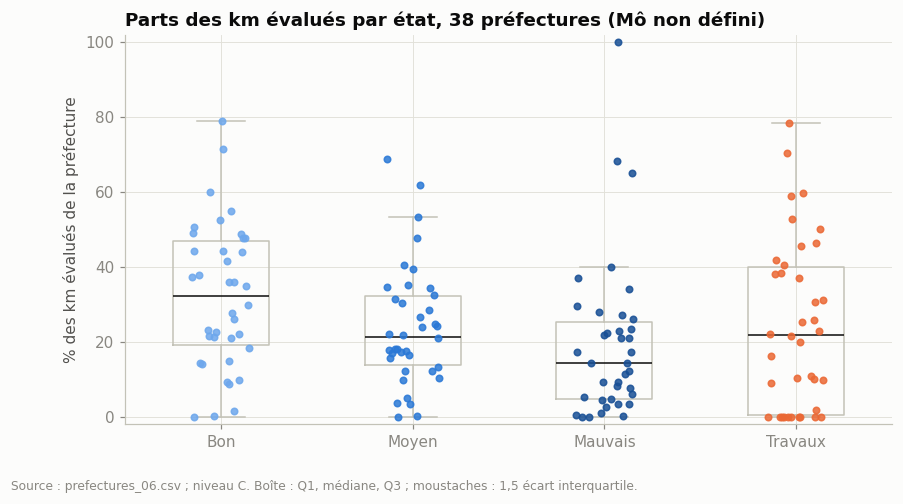

,Effectif,Non définis,Minimum,Q1,Médiane,Q3,Maximum,Valeurs atypiques
Variable,,,,,,,,
Part en mauvais état (%),38,1,0.0,4.750,14.35,25.325,100.0,"Danyi (100,0) ; Blitta (68,2) ; Kloto (65,0)"
Part en travaux (%),38,1,0.0,0.425,21.85,39.950,78.5,NaN


In [4]:
etats = ["Part en bon état (%)", "Part en état moyen (%)", "Part en mauvais état (%)", "Part en travaux (%)"]
fig, ax = plt.subplots(figsize=(9, 4.6))
donnees = [p[e].dropna() for e in etats]
ax.boxplot(donnees, tick_labels=["Bon", "Moyen", "Mauvais", "Travaux"], widths=0.5, showfliers=False,
           medianprops={"color": ENCRE}, boxprops={"color": AXE}, whiskerprops={"color": AXE}, capprops={"color": AXE})
rng = np.random.default_rng(0)
for i, (couleur, d) in enumerate(zip([ETAT_COULEURS[e] for e in ["Bon", "Moyen", "Mauvais", "Travaux"]], donnees), start=1):
    ax.scatter(i + rng.uniform(-0.15, 0.15, len(d)), d, s=18, color=couleur, alpha=0.85, zorder=3)
ax.set_ylim(-2, 102); ax.set_ylabel("% des km évalués de la préfecture")
ax.set_title("Parts des km évalués par état, 38 préfectures (Mô non défini)")
pied(fig, "Source : prefectures_06.csv ; niveau C. Boîte : Q1, médiane, Q3 ; moustaches : 1,5 écart interquartile.")
plt.show()
display(exploration("distributions").set_index("Variable").loc[["Part en mauvais état (%)", "Part en travaux (%)"],
        ["Effectif", "Non définis", "Minimum", "Q1", "Médiane", "Q3", "Maximum", "Valeurs atypiques"]])

## Part du réseau national non évaluée (O3-06)

Hachures : préfectures sans aucun km non évalué (zéro mesuré). Mô : non défini.

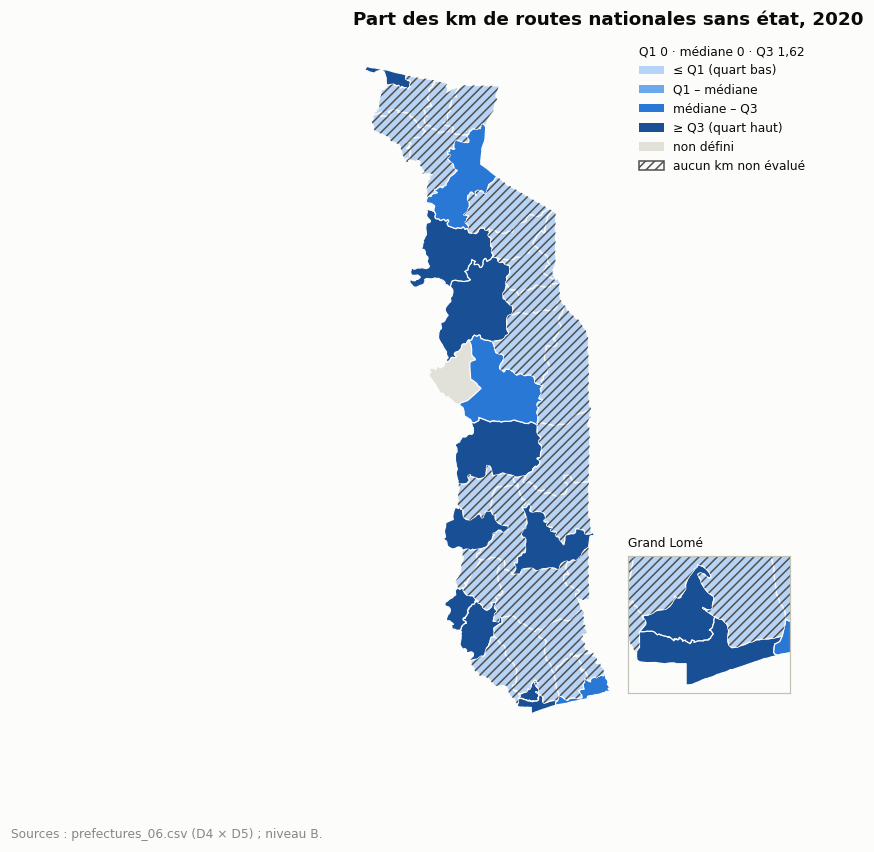

,Zone,Km de routes nationales,Km non évalués,Part non évaluée (%)
Préfecture,,,,
Agou,Plateaux,115.2,2.2,1.9
Agoè-Nyivé,Grand Lomé,35.7,7.1,20.0
Bassar,Kara,182.1,31.4,17.2
Blitta,Centrale,118.5,23.5,19.8
Cinkassé,Savanes,39.3,4.4,11.3
Dankpen,Kara,45.1,1.7,3.7
Golfe,Grand Lomé,78.6,9.6,12.2
Kloto,Plateaux,66.7,3.6,5.4
Lacs,Maritime hors Grand Lomé,81.6,0.8,1.0


In [5]:
fig, ax, g = choroplethe(p, "Part non évaluée (%)", "Part des km de routes nationales sans état, 2020",
                        "Sources : prefectures_06.csv (D4 × D5) ; niveau B.", zero="aucun km non évalué")
plt.show()
display(p.loc[p["Km non évalués"] > 0, ["Préfecture", "Zone", "Km de routes nationales", "Km non évalués", "Part non évaluée (%)"]].set_index("Préfecture"))

## Km par type de route nationale et par état, 6 zones (O3-04)

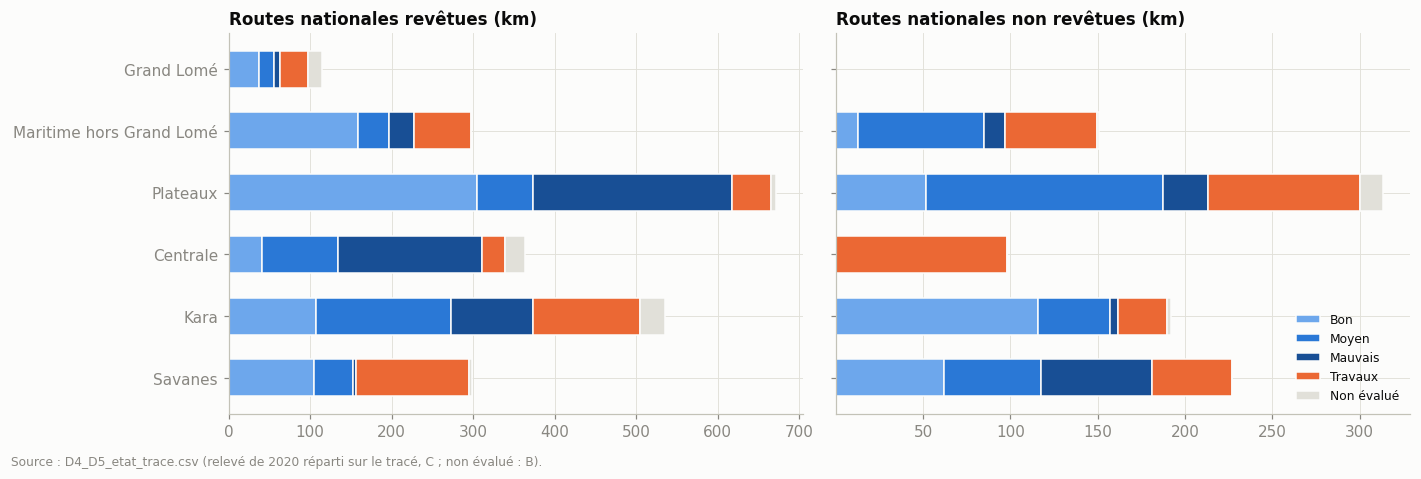

État                                      Bon  Moyen  Mauvais  Travaux  Non évalué
Zone                     Type de route                                            
Centrale                 non revêtue      0.0    0.2      0.1     98.1         NaN
                         revêtue         41.4   93.3    176.3     27.9        24.6
Grand Lomé               revêtue         37.1   18.2      7.6     34.9        16.7
Kara                     non revêtue    116.0   40.7      4.7     28.5         2.1
                         revêtue        107.4  165.6    100.7    130.8        30.9
Maritime hors Grand Lomé non revêtue     12.8   72.2     12.0     52.8         0.8
                         revêtue        159.0   38.1     30.6     69.8         NaN
Plateaux                 non revêtue     51.9  135.3     26.1     86.9        13.1
                         revêtue        304.3   68.8    244.6     47.7         5.8
Savanes                  non revêtue     62.1   55.4     63.8     45.5         NaN
                         revêtue        104.8   47.8      3.0    138.7         4.8

In [6]:
e = lire("D4_D5_etat_trace")
t = e.groupby(["Zone", "Type de route", "État"])["km"].sum().unstack("État").reindex(columns=["Bon", "Moyen", "Mauvais", "Travaux", "Non évalué"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, type_ in zip(axes, ["revêtue", "non revêtue"]):
    d = t.xs(type_, level="Type de route").reindex(ZONES).fillna(0)
    gauche = np.zeros(len(d))
    for etat in d.columns:
        couleur = ETAT_COULEURS[etat]
        ax.barh(d.index, d[etat], left=gauche, color=couleur, edgecolor=SURFACE, linewidth=1, label=etat, height=0.6)
        gauche += d[etat].to_numpy()
    ax.set_title(f"Routes nationales {type_}s (km)", fontsize=11)
axes[0].invert_yaxis(); axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
pied(fig, "Source : D4_D5_etat_trace.csv (relevé de 2020 réparti sur le tracé, C ; non évalué : B).")
plt.show()
display(t.round(1))

## Tronçons du relevé, par part en mauvais état (O3-05)

Couleur continue, sans classe ; en gris, les routes nationales sans tronçon rattaché (non évaluées).

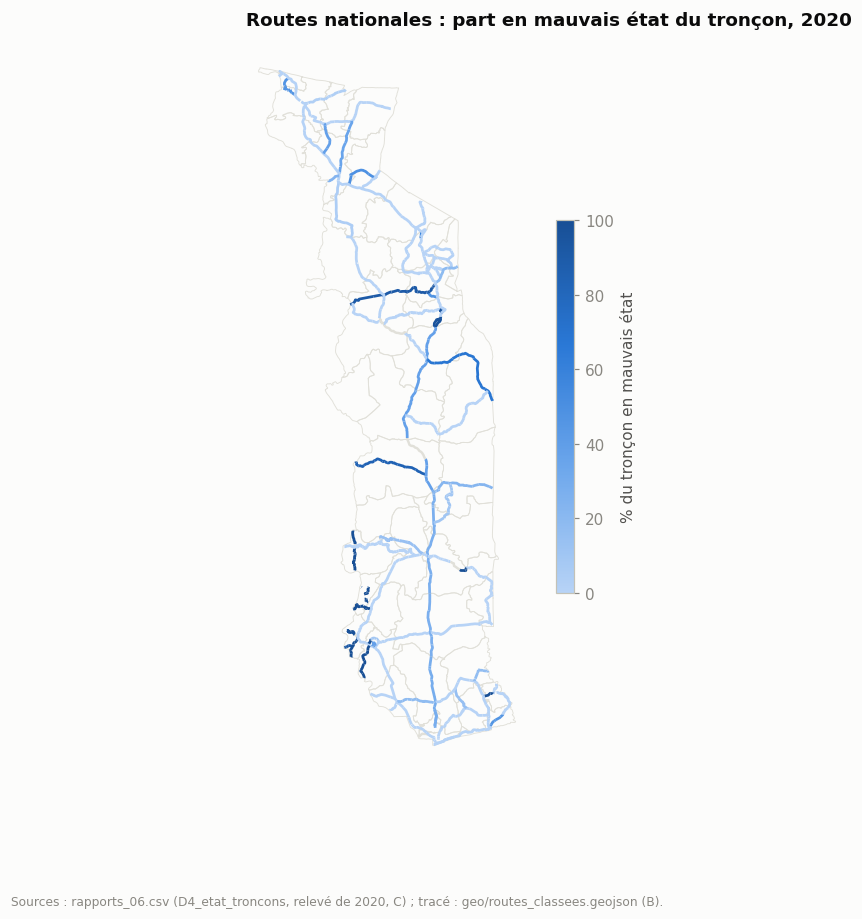

count     81.0
mean      32.5
std       40.6
min        0.0
25%        0.0
50%        9.2
75%       68.4
max      100.0
Name: Valeur, dtype: float64

In [7]:
from matplotlib.colors import LinearSegmentedColormap
routes = gpd.read_file(TRAITE / "geo" / "routes_classees.geojson").to_crs(UTM31N)
nat = routes[routes["Type"].str.startswith("Route nationale")]
tr = rapport("Part en mauvais état", maille="Tronçon")
nom_part = {nom: v for noms, v in zip(tr["Territoire"], tr["Valeur"]) for nom in noms.split(" | ")}
nat = nat.assign(part=nat["Nom"].map(nom_part))
cmap = LinearSegmentedColormap.from_list("bleus", SEQUENTIEL)
fig, ax = plt.subplots(figsize=(6.4, 8.8))
p.boundary.plot(ax=ax, color=GRILLE, linewidth=0.6)
nat[nat["part"].isna()].plot(ax=ax, color=NON_DEFINI, linewidth=1.6)
nat[nat["part"].notna()].plot(ax=ax, column="part", cmap=cmap, vmin=0, vmax=100, linewidth=1.8, legend=True,
                              legend_kwds={"label": "% du tronçon en mauvais état", "shrink": 0.5})
nettoyer(ax)
ax.set_title("Routes nationales : part en mauvais état du tronçon, 2020")
pied(fig, "Sources : rapports_06.csv (D4_etat_troncons, relevé de 2020, C) ; tracé : geo/routes_classees.geojson (B).")
plt.show()
display(tr["Valeur"].describe().round(1))

## État national, 2020–2022 (O3-07)

Annuaire 2024, tableau 39.2, en C. Le « - » de 2020 (routes non revêtues en travaux) reste vide (R-10).

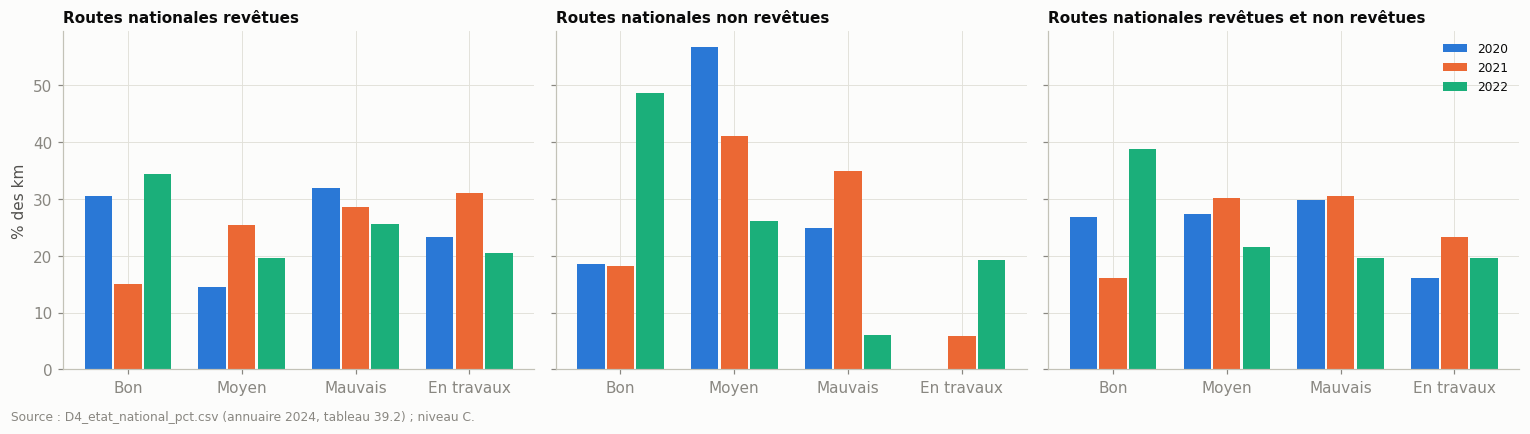

Année                                                   2020   2021   2022
Catégorie de route                         État                           
Routes nationales non revêtues             Bon         18.55  18.21  48.63
                                           En travaux    NaN   5.96  19.25
                                           Mauvais     24.84  34.80   6.02
                                           Moyen       56.61  41.03  26.10
Routes nationales revêtues                 Bon         30.45  15.09  34.30
                                           En travaux  23.21  31.00  20.46
                                           Mauvais     31.93  28.55  25.60
                                           Moyen       14.41  25.38  19.54
Routes nationales revêtues et non revêtues Bon         26.79  16.06  38.67
                                           En travaux  16.06  23.29  19.63
                                           Mauvais     29.75  30.47  19.63
                                           Moyen       27.40  30.20  21.61

In [8]:
n = lire("D4_etat_national_pct")
cats = n["Catégorie de route"].unique()
fig, axes = plt.subplots(1, len(cats), figsize=(14, 3.8), sharey=True)
for ax, cat in zip(axes, cats):
    d = n[n["Catégorie de route"] == cat].pivot(index="État", columns="Année", values="Part (%)").reindex(["Bon", "Moyen", "Mauvais", "En travaux"])
    x = np.arange(len(d))
    for i, (couleur, an) in enumerate(zip(SERIES, d.columns)):
        ax.bar(x + (i - 1) * 0.26, d[an], width=0.24, color=couleur, label=str(an))
    ax.set_xticks(x, d.index); ax.set_title(cat, fontsize=10)
axes[0].set_ylabel("% des km"); axes[-1].legend(fontsize=8)
fig.tight_layout()
pied(fig, "Source : D4_etat_national_pct.csv (annuaire 2024, tableau 39.2) ; niveau C.")
plt.show()
display(n.pivot_table(index=["Catégorie de route", "État"], columns="Année", values="Part (%)"))

## Même année, deux publications : relevé de 2020 et annuaire 39.2 (06 §5)

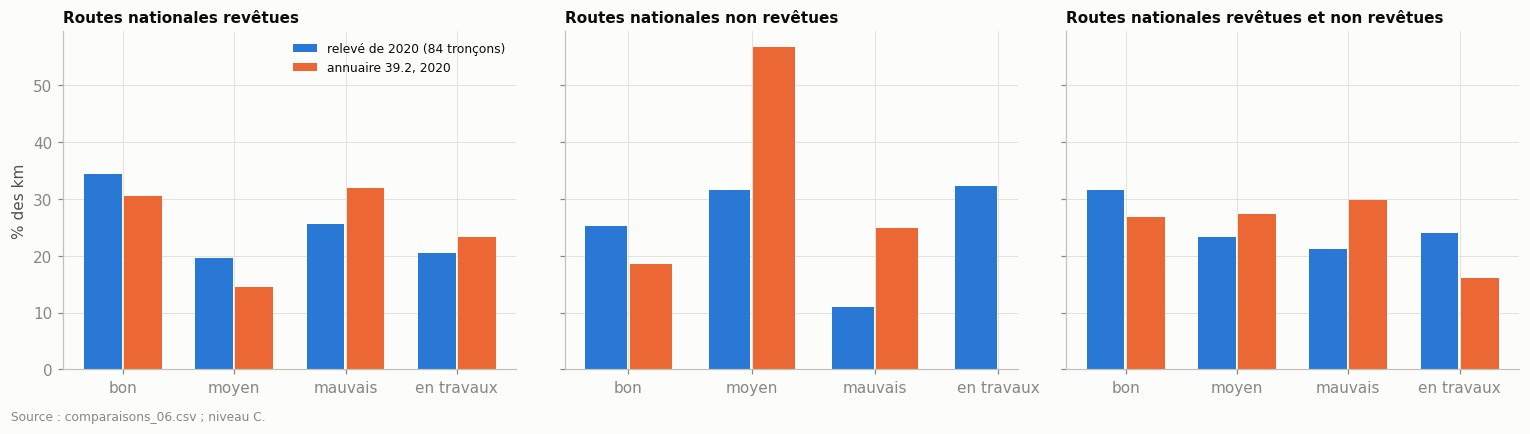

,Valeur 1,Valeur 2,Écart (points),Identiques,Note
Élément,,,,,
Routes nationales revêtues : bon,34.30,30.45,3.85,False,NaN
Routes nationales revêtues : moyen,19.64,14.41,5.23,False,NaN
Routes nationales revêtues : mauvais,25.60,31.93,-6.33,False,NaN
Routes nationales revêtues : en travaux,20.46,23.21,-2.75,False,NaN
Routes nationales non revêtues : bon,25.17,18.55,6.62,False,NaN
Routes nationales non revêtues : moyen,31.47,56.61,-25.14,False,NaN
Routes nationales non revêtues : mauvais,11.04,24.84,-13.80,False,NaN
Routes nationales non revêtues : en travaux,32.31,NaN,NaN,NaN,« - » dans l’annuaire : non renseigné (R-10)
Routes nationales revêtues et non revêtues : bon,31.52,26.79,4.73,False,NaN


In [9]:
c = exploration("comparaisons")
c = c[c["Comparaison"].str.startswith("État")].assign(Catégorie=lambda d: d["Élément"].str.split(" : ").str[0],
                                                       État=lambda d: d["Élément"].str.split(" : ").str[1])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (cat, d) in zip(axes, c.groupby("Catégorie", sort=False)):
    x = np.arange(len(d))
    ax.bar(x - 0.18, d["Valeur 1"], width=0.34, color=SERIES[0], label="relevé de 2020 (84 tronçons)")
    ax.bar(x + 0.18, d["Valeur 2"], width=0.34, color=SERIES[1], label="annuaire 39.2, 2020")
    ax.set_xticks(x, d["État"]); ax.set_title(cat, fontsize=10)
axes[0].set_ylabel("% des km"); axes[0].legend(fontsize=8)
fig.tight_layout()
pied(fig, "Source : comparaisons_06.csv ; niveau C.")
plt.show()
display(c[["Élément", "Valeur 1", "Valeur 2", "Écart (points)", "Identiques", "Note"]].set_index("Élément"))

## Signaux de O3 (`signaux_06.csv`)

In [10]:
display(signaux(objectif="O3"))

,Résumé,Niveau,Question transmise
ID,,,
SIG-20,"Part en mauvais état (%) : 3 préfecture(s) hors des bornes de Tukey (-26,11 ; 56,19) : Danyi (100,0) ; Blitta (68,2) ; Kloto (65,0)",C,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-21,"Part non évaluée (%) : 7 préfecture(s) hors des bornes de Tukey (-2,44 ; 4,06) : Agoè-Nyivé (20,0) ; Blitta (19,8) ; Bassar (17,2) ; Gol...",B,"Le classement tient-il sans ces valeurs ? Le 08 le vérifie (sensibilité au point extrême, 05_Priorisation)."
SIG-27,"État national de 2020 : 11 part(s) sur 11 diffèrent entre le relevé et l’annuaire 39.2 ; écart maximal -25,14 points (Routes nationales ...",C,Les deux publications de 2020 diffèrent : le 07 dit laquelle porte O3-07 et laquelle porte O3-01 à O3-06.
SIG-33,"Contradiction 2a : 9 préfecture(s) au réseau hors du quart bas et à part en mauvais état haute : Agou, Bassar, Blitta, Danyi, Kloto, Ogo...",C,Ici le réseau existe mais il est dégradé : le 07 lit-il ces préfectures sur l’état (O3-02) plutôt que sur la quantité (O4-03) ?
SIG-44,Contradiction 5 (réseau) : 1 préfecture(s) traversée(s) par un seul tronçon du relevé : Tandjoaré (138 867 habitants) ; sans route class...,C,Tout le réseau national évalué tient en un tronçon : son état dit l’état de la préfecture. Le 07 l’affiche avec cette réserve.
